# Analiza słowników

Ten notatnik pokazuje analizę słowników języka polskiego, angielskiego, niemieckiego i francuskiego pod kątem struktur kombinatorycznych na słowach.

Pierwsza część analizuje całe słowa, czyli dla każdego hasła sprawdzamy wynik metod `check(...)` z detektorów. Końcowa sekcja rozszerza analizę o spójne fragmenty słów będące kwadratami albo kwadratami abelowymi.

## Założenia

Notebook zakłada, że słowniki są już pobrane i znajdują się w katalogu `data/raw/`:

- `data/raw/pl.txt`,
- `data/raw/en.txt`,
- `data/raw/de.txt`,
- `data/raw/fr.txt`.

Jeżeli plików brakuje, należy wcześniej uruchomić w terminalu `make data` albo `uv run python -m natural_languages.data.fetch`. Notebook celowo nie pobiera danych automatycznie.

## 1. Przygotowanie środowiska

Importujemy biblioteki, konfigurujemy styl wykresów i ustawiamy ścieżkę projektu tak, aby notebook można było uruchomić z katalogu `docs/` albo z głównego katalogu repozytorium.

In [27]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "natural_languages").is_dir():
            return path
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from natural_languages.data import DataLoader, TextPreprocessor  # noqa: E402
from natural_languages.detectors import (  # noqa: E402
    AbelianSquareDetector,
    AnagramDetector,
    PalindromeDetector,
    ShuffledSquareDetector,
    SquareDetector,
    TangramDetector,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 80)


## 2. Stałe analizy

Ustalamy analizowane języki, etykiety struktur oraz limit długości dla przetasowanych kwadratów. Limit `MAX_SHUFFLED_LEN = 16` zabezpiecza notebook przed bardzo wolną analizą, ponieważ detekcja przetasowanych kwadratów jest kosztowna obliczeniowo.

In [28]:
LANGUAGES = ["pl", "en", "de", "fr"]
LANGUAGE_LABELS = {
    "pl": "polski",
    "en": "angielski",
    "de": "niemiecki",
    "fr": "francuski",
}

STRUCTURES = [
    "square",
    "palindrome",
    "abelian_square",
    "tangram",
    "shuffled_square",
]
STRUCTURE_LABELS = {
    "square": "kwadrat",
    "palindrome": "palindrom",
    "abelian_square": "kwadrat abelowy",
    "tangram": "tangram",
    "shuffled_square": "przetasowany kwadrat",
}

DATA_DIR = PROJECT_ROOT / "data" / "raw"
MIN_WORD_LENGTH = 2
MAX_SHUFFLED_LEN = 16
TOP_EXAMPLES_PER_STRUCTURE = 3

detectors = {
    "square": SquareDetector(),
    "palindrome": PalindromeDetector(),
    "abelian_square": AbelianSquareDetector(),
    "tangram": TangramDetector(),
    "shuffled_square": ShuffledSquareDetector(),
}
anagram_detector = AnagramDetector()
preprocessor = TextPreprocessor()

pd.DataFrame(
    [
        {"parametr": "języki", "wartość": ", ".join(LANGUAGES)},
        {"parametr": "minimalna długość słowa", "wartość": MIN_WORD_LENGTH},
        {"parametr": "limit przetasowanych kwadratów", "wartość": MAX_SHUFFLED_LEN},
        {"parametr": "top przykładów w tabeli", "wartość": TOP_EXAMPLES_PER_STRUCTURE},
    ]
)

,parametr,wartość
0,języki,"pl, en, de, fr"
1,minimalna długość słowa,2
2,limit przetasowanych kwadratów,16
3,top przykładów w tabeli,3


## 3. Wczytanie słowników

Wczytujemy pliki tekstowe, normalizujemy słowa, usuwamy puste wpisy, deduplikujemy listy i odrzucamy słowa jednoznakowe

In [29]:
word_rows = []
for language in LANGUAGES:
    path = DATA_DIR / f"{language}.txt"
    raw_words = DataLoader(path).load_word_list()
    normalized_words = preprocessor.normalize_words(raw_words)
    unique_words = [word for word in dict.fromkeys(normalized_words) if len(word) >= MIN_WORD_LENGTH]

    for word in unique_words:
        word_rows.append(
            {
                "language": language,
                "language_label": LANGUAGE_LABELS[language],
                "word": word,
                "length": len(word),
            }
        )

words_df = pd.DataFrame(word_rows)

dictionary_overview_table_df = (
    words_df.groupby(["language", "language_label"], as_index=False)
    .agg(liczba_słów=("word", "size"), min_długość=("length", "min"), max_długość=("length", "max"), średnia_długość=("length", "mean"))
    .assign(średnia_długość=lambda df: df["średnia_długość"].round(2))
)

display(dictionary_overview_table_df)
display(words_df.head(10))

,language,language_label,liczba_słów,min_długość,max_długość,średnia_długość
0,de,niemiecki,163733,2,67,12.03
1,en,angielski,48166,2,23,7.83
2,fr,francuski,79090,2,32,9.22
3,pl,polski,343038,2,33,10.51


,language,language_label,word,length
0,pl,polski,aa,2
1,pl,polski,aaa,3
2,pl,polski,aachen,6
3,pl,polski,aalborg,7
4,pl,polski,aalborski,9
5,pl,polski,aalto,5
6,pl,polski,aan,3
7,pl,polski,aap,3
8,pl,polski,aara,4
9,pl,polski,aardvark,8


## 4. Analiza struktur

Dla każdego słowa sprawdzamy, czy całe słowo jest daną strukturą.

Dla przetasowanych kwadratów analizujemy tylko słowa parzystej długości, nie dłuższe niż `MAX_SHUFFLED_LEN`, które spełniają warunek tangramu.

In [30]:
analysis_rows = []

for language in LANGUAGES:
    language_words = words_df.loc[words_df["language"] == language, "word"].tolist()
    print(f"Analizuję język: {LANGUAGE_LABELS[language]} ({len(language_words)} słów)")

    for word in language_words:
        word_length = len(word)
        is_square = detectors["square"].check(word)
        is_palindrome = detectors["palindrome"].check(word)
        is_abelian_square = detectors["abelian_square"].check(word)
        is_tangram = detectors["tangram"].check(word)
        is_shuffled_square = (
            is_tangram
            and word_length <= MAX_SHUFFLED_LEN
            and word_length % 2 == 0
            and detectors["shuffled_square"].check(word)
        )

        analysis_rows.append(
            {
                "language": language,
                "language_label": LANGUAGE_LABELS[language],
                "word": word,
                "length": word_length,
                "square": is_square,
                "palindrome": is_palindrome,
                "abelian_square": is_abelian_square,
                "tangram": is_tangram,
                "shuffled_square": is_shuffled_square,
            }
        )

analysis_df = pd.DataFrame(analysis_rows)

print(f"Gotowe: {len(analysis_df)} przeanalizowanych słów.")
display(analysis_df.head(10))

Analizuję język: polski (343038 słów)
Analizuję język: angielski (48166 słów)
Analizuję język: niemiecki (163733 słów)
Analizuję język: francuski (79090 słów)
Gotowe: 634027 przeanalizowanych słów.


,language,language_label,word,length,square,palindrome,abelian_square,tangram,shuffled_square
0,pl,polski,aa,2,True,True,True,True,True
1,pl,polski,aaa,3,False,True,False,False,False
2,pl,polski,aachen,6,False,False,False,False,False
3,pl,polski,aalborg,7,False,False,False,False,False
4,pl,polski,aalborski,9,False,False,False,False,False
5,pl,polski,aalto,5,False,False,False,False,False
6,pl,polski,aan,3,False,False,False,False,False
7,pl,polski,aap,3,False,False,False,False,False
8,pl,polski,aara,4,False,False,False,False,False
9,pl,polski,aardvark,8,False,False,False,False,False


## 5. DataFrame'y pod wykresy i tabele

In [31]:
summary_rows = []
for language in LANGUAGES:
    language_df = analysis_df[analysis_df["language"] == language]
    total_words = len(language_df)
    for structure in STRUCTURES:
        count = int(language_df[structure].sum())
        summary_rows.append(
            {
                "language": language,
                "language_label": LANGUAGE_LABELS[language],
                "structure": structure,
                "structure_label": STRUCTURE_LABELS[structure],
                "count": count,
                "total_words": total_words,
                "percent": 100.0 * count / total_words if total_words else 0.0,
            }
        )

structure_summary_df = pd.DataFrame(summary_rows)

structure_counts_plot_df = structure_summary_df[["language", "language_label", "structure", "structure_label", "count"]].copy()
structure_percent_plot_df = structure_summary_df[["language", "language_label", "structure", "structure_label", "percent"]].copy()
language_structure_heatmap_df = structure_percent_plot_df.pivot(
    index="language_label", columns="structure_label", values="percent"
).loc[[LANGUAGE_LABELS[language] for language in LANGUAGES], [STRUCTURE_LABELS[structure] for structure in STRUCTURES]]

length_profile_rows = []
for language in LANGUAGES:
    language_df = analysis_df[analysis_df["language"] == language]
    for structure in STRUCTURES:
        counts_by_length = language_df[language_df[structure]].groupby("length").size()
        for length, count in counts_by_length.items():
            length_profile_rows.append(
                {
                    "language": language,
                    "language_label": LANGUAGE_LABELS[language],
                    "structure": structure,
                    "structure_label": STRUCTURE_LABELS[structure],
                    "length": int(length),
                    "count": int(count),
                }
            )
length_profiles_plot_df = pd.DataFrame(length_profile_rows)

cooccurrence_rows = []
for left in STRUCTURES:
    row = {}
    for right in STRUCTURES:
        row[STRUCTURE_LABELS[right]] = int((analysis_df[left] & analysis_df[right]).sum())
    cooccurrence_rows.append(row)
cooccurrence_matrix_df = pd.DataFrame(cooccurrence_rows, index=[STRUCTURE_LABELS[structure] for structure in STRUCTURES])

anagram_scale_rows = []
for language in LANGUAGES:
    words = analysis_df.loc[analysis_df["language"] == language, "word"].tolist()
    groups = anagram_detector.find_groups(words)
    words_in_groups = sum(len(group) for group in groups)
    anagram_scale_rows.extend(
        [
            {"language": language, "language_label": LANGUAGE_LABELS[language], "metric": "grupy anagramów", "value": len(groups)},
            {"language": language, "language_label": LANGUAGE_LABELS[language], "metric": "słowa w grupach", "value": words_in_groups},
            {"language": language, "language_label": LANGUAGE_LABELS[language], "metric": "największa grupa", "value": max((len(group) for group in groups), default=0)},
        ]
    )
anagram_scale_plot_df = pd.DataFrame(anagram_scale_rows)

longest_rows = []
for language in LANGUAGES:
    language_df = analysis_df[analysis_df["language"] == language]
    for structure in STRUCTURES:
        examples = language_df[language_df[structure]].sort_values(["length", "word"], ascending=[False, True]).head(
            TOP_EXAMPLES_PER_STRUCTURE
        )
        for rank, row in enumerate(examples.itertuples(index=False), start=1):
            longest_rows.append(
                {
                    "język": LANGUAGE_LABELS[language],
                    "struktura": STRUCTURE_LABELS[structure],
                    "miejsce": rank,
                    "słowo": row.word,
                    "długość": row.length,
                }
            )
longest_examples_table_df = pd.DataFrame(longest_rows)

ranking_rows = []
for structure in STRUCTURES:
    ranked = structure_summary_df[structure_summary_df["structure"] == structure].sort_values(
        ["percent", "count", "language_label"], ascending=[False, False, True]
    )
    for rank, row in enumerate(ranked.itertuples(index=False), start=1):
        ranking_rows.append(
            {
                "struktura": STRUCTURE_LABELS[structure],
                "miejsce": rank,
                "język": row.language_label,
                "liczba słów": row.count,
                "procent": round(row.percent, 4),
            }
        )
language_ranking_table_df = pd.DataFrame(ranking_rows)

pd.DataFrame(
    [
        {"DataFrame": "structure_counts_plot_df", "wiersze": len(structure_counts_plot_df)},
        {"DataFrame": "structure_percent_plot_df", "wiersze": len(structure_percent_plot_df)},
        {"DataFrame": "language_structure_heatmap_df", "wiersze": len(language_structure_heatmap_df)},
        {"DataFrame": "length_profiles_plot_df", "wiersze": len(length_profiles_plot_df)},
        {"DataFrame": "cooccurrence_matrix_df", "wiersze": len(cooccurrence_matrix_df)},
        {"DataFrame": "anagram_scale_plot_df", "wiersze": len(anagram_scale_plot_df)},
        {"DataFrame": "longest_examples_table_df", "wiersze": len(longest_examples_table_df)},
        {"DataFrame": "language_ranking_table_df", "wiersze": len(language_ranking_table_df)},
    ]
)

,DataFrame,wiersze
0,structure_counts_plot_df,20
1,structure_percent_plot_df,20
2,language_structure_heatmap_df,4
3,length_profiles_plot_df,121
4,cooccurrence_matrix_df,5
5,anagram_scale_plot_df,12
6,longest_examples_table_df,60
7,language_ranking_table_df,20


## 6. Liczebność struktur

Wykres pokazuje, ile słów w każdym słowniku spełnia definicję danej struktury. Dane wejściowe: `structure_counts_plot_df`.

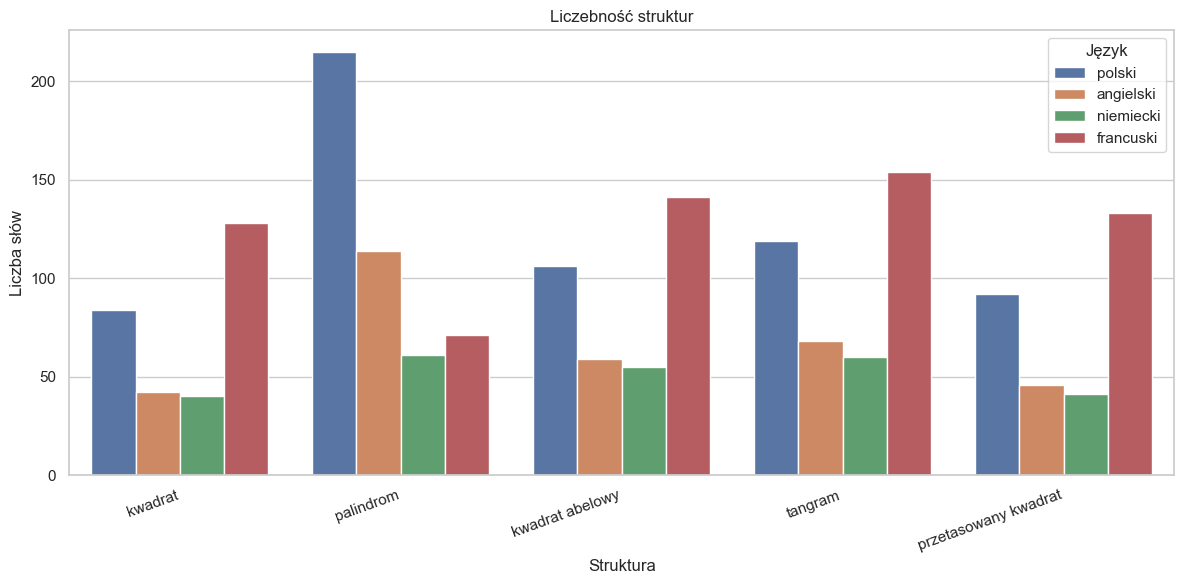

In [32]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=structure_counts_plot_df,
    x="structure_label",
    y="count",
    hue="language_label",
)
ax.set_title("Liczebność struktur")
ax.set_xlabel("Struktura")
ax.set_ylabel("Liczba słów")
ax.legend(title="Język")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 7. Procentowy udział struktur w słowniku

Ponieważ słowniki mogą mieć różną liczbę haseł, porównanie procentowe jest bardziej miarodajne niż same liczby bezwzględne. Dane wejściowe: `structure_percent_plot_df`.

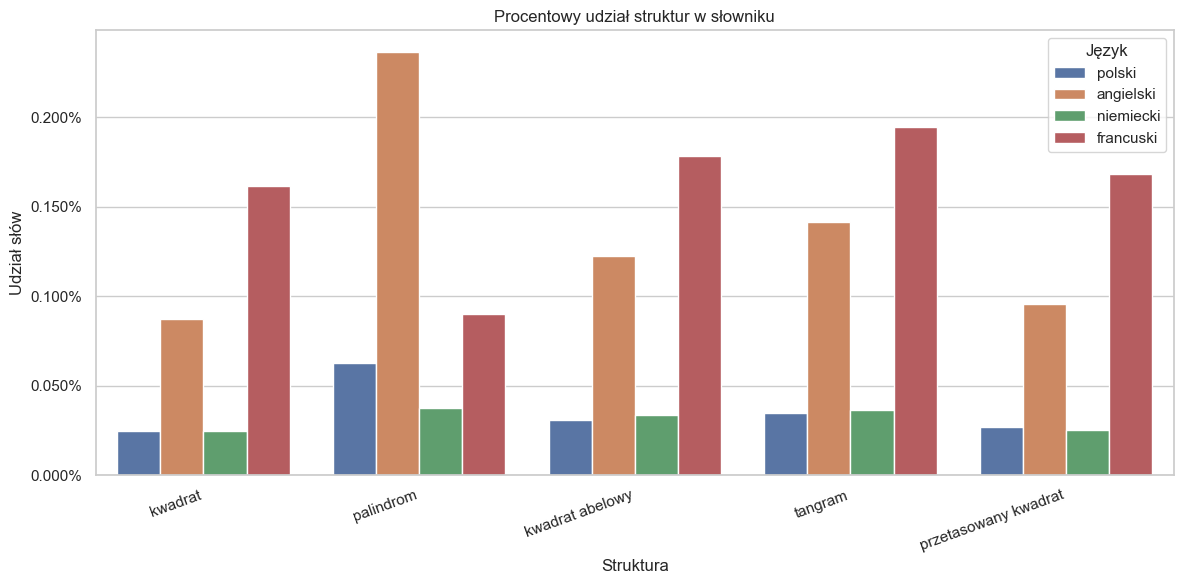

In [33]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=structure_percent_plot_df,
    x="structure_label",
    y="percent",
    hue="language_label",
)
ax.set_title("Procentowy udział struktur w słowniku")
ax.set_xlabel("Struktura")
ax.set_ylabel("Udział słów")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.legend(title="Język")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 8. Heatmapa język × struktura w procentach

Heatmapa pokazuje udział procentowy struktur w słownikach. Dane wejściowe: `language_structure_heatmap_df`.

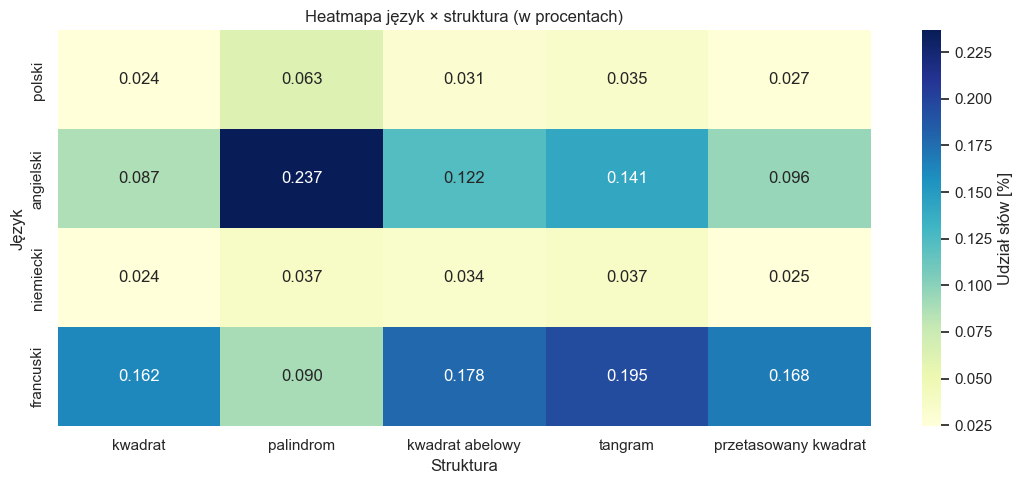

In [34]:
plt.figure(figsize=(11, 5))
ax = sns.heatmap(
    language_structure_heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={"label": "Udział słów [%]"},
)
ax.set_title("Heatmapa język × struktura (w procentach)")
ax.set_xlabel("Struktura")
ax.set_ylabel("Język")
plt.tight_layout()
plt.show()

## 9. Profile długości dla poszczególnych struktur

Profile długości pokazują, dla jakich długości słów pojawiają się dane struktury. Dane wejściowe: `length_profiles_plot_df`.

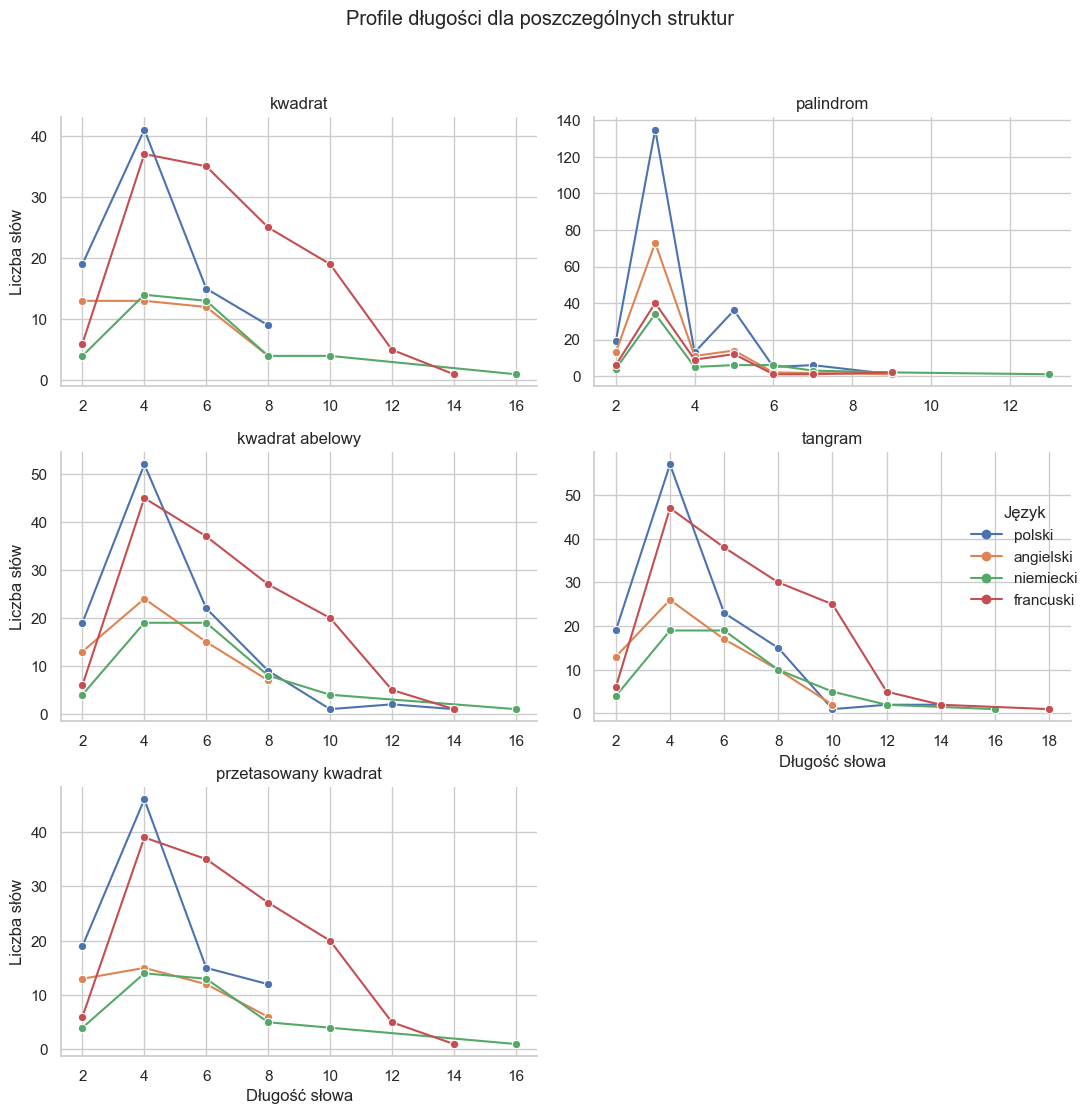

In [35]:
g = sns.relplot(
    data=length_profiles_plot_df,
    x="length",
    y="count",
    hue="language_label",
    col="structure_label",
    col_wrap=2,
    kind="line",
    marker="o",
    height=3.6,
    aspect=1.35,
    facet_kws={"sharey": False, "sharex": False},
)
g.set_axis_labels("Długość słowa", "Liczba słów")
for ax in g.axes.flat:
    ax.set_title(ax.get_title().replace("structure_label = ", ""))
if g._legend is not None:
    g._legend.set_title("Język")
g.figure.suptitle("Profile długości dla poszczególnych struktur", y=1.03)
g.figure.tight_layout()
plt.show()

## 10. Macierz współwystępowania struktur

Macierz pokazuje, ile słów w całym analizowanym zbiorze spełnia jednocześnie dwie definicje struktur. Przekątna macierzy to liczebność pojedynczych struktur. Dane wejściowe: `cooccurrence_matrix_df`.

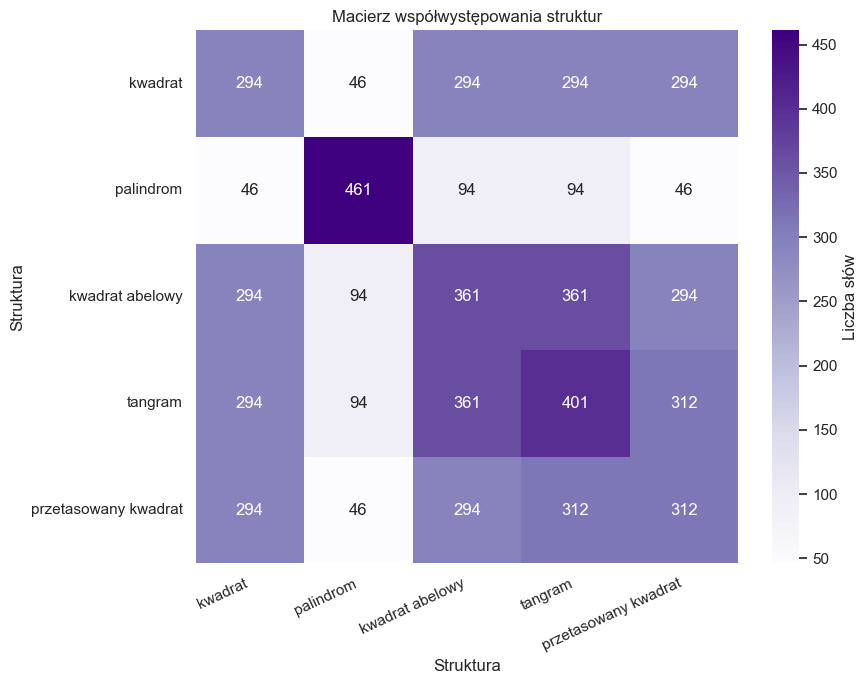

In [36]:
plt.figure(figsize=(9, 7))
ax = sns.heatmap(
    cooccurrence_matrix_df,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar_kws={"label": "Liczba słów"},
)
ax.set_title("Macierz współwystępowania struktur")
ax.set_xlabel("Struktura")
ax.set_ylabel("Struktura")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Anagramy: skala zjawiska z podziałem na język

Dla każdego języka grupujemy słowa o tym samym rozkładzie liter. Wykres pokazuje liczbę grup anagramów, liczbę słów należących do takich grup oraz rozmiar największej grupy. Dane wejściowe: `anagram_scale_plot_df`.

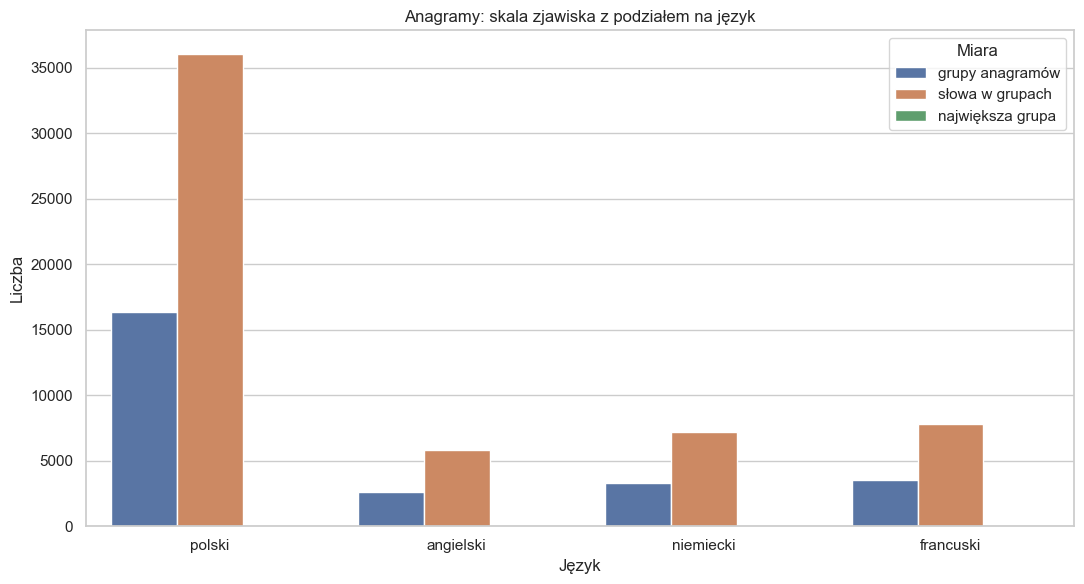

In [37]:
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=anagram_scale_plot_df,
    x="language_label",
    y="value",
    hue="metric",
)
ax.set_title("Anagramy: skala zjawiska z podziałem na język")
ax.set_xlabel("Język")
ax.set_ylabel("Liczba")
ax.legend(title="Miara")
plt.tight_layout()
plt.show()

## 12. Najdłuższe przykłady struktur

Tabela pokazuje najdłuższe znalezione słowa dla każdej struktury i każdego języka. Dane wejściowe: `longest_examples_table_df`.

In [38]:
display(longest_examples_table_df)

,język,struktura,miejsce,słowo,długość
0,polski,kwadrat,1,dziadzia,8
1,polski,kwadrat,2,froufrou,8
2,polski,kwadrat,3,karakara,8
3,polski,palindrom,1,malajalam,9
4,polski,palindrom,2,anilina,7
5,polski,palindrom,3,apokopa,7
6,polski,kwadrat abelowy,1,niedziadzienia,14
7,polski,kwadrat abelowy,2,kryptoportyk,12
8,polski,kwadrat abelowy,3,niechachanie,12
9,polski,tangram,1,niedziadzienia,14


## 13. Ranking języków dla każdej struktury

Ranking sortuje języki według procentowego udziału danej struktury w słowniku. Dane wejściowe: `language_ranking_table_df`.

In [39]:
display(language_ranking_table_df)

,struktura,miejsce,język,liczba słów,procent
0,kwadrat,1,francuski,128,0.1618
1,kwadrat,2,angielski,42,0.0872
2,kwadrat,3,polski,84,0.0245
3,kwadrat,4,niemiecki,40,0.0244
4,palindrom,1,angielski,114,0.2367
5,palindrom,2,francuski,71,0.0898
6,palindrom,3,polski,215,0.0627
7,palindrom,4,niemiecki,61,0.0373
8,kwadrat abelowy,1,francuski,141,0.1783
9,kwadrat abelowy,2,angielski,59,0.1225


## 14. Analiza fragmentów będących kwadratami i kwadratami abelowymi

W tej sekcji nie ograniczamy się do całych słów. Dla każdego słowa szukamy spójnych fragmentów, które są zwykłymi kwadratami albo kwadratami abelowymi.

Przykład: w słowie `kankan` fragment `kankan` jest kwadratem, bo `kankan = kan + kan`. W słowie `abba` fragment `abba` jest kwadratem abelowym, bo `abba = ab + ba`, a `ab` i `ba` mają te same częstości liter.

In [40]:
SUBSTRING_STRUCTURES = ["square", "abelian_square"]
SUBSTRING_STRUCTURE_LABELS = {
    "square": "kwadrat",
    "abelian_square": "kwadrat abelowy",
}
TOP_SUBSTRUCTURE_WORDS = 10

substring_match_columns = [
    "language",
    "language_label",
    "word",
    "word_length",
    "structure",
    "structure_label",
    "fragment",
    "start",
    "end",
    "fragment_length",
    "generator_length",
    "parts",
]
substring_match_rows = []

for language in LANGUAGES:
    language_df = analysis_df.loc[analysis_df["language"] == language, ["language", "language_label", "word", "length"]]
    print(f"Szukam fragmentów: {LANGUAGE_LABELS[language]} ({len(language_df)} słów)")

    for row in language_df.itertuples(index=False):
        for structure in SUBSTRING_STRUCTURES:
            for match in detectors[structure].find(row.word):
                substring_match_rows.append(
                    {
                        "language": row.language,
                        "language_label": row.language_label,
                        "word": row.word,
                        "word_length": row.length,
                        "structure": structure,
                        "structure_label": SUBSTRING_STRUCTURE_LABELS[structure],
                        "fragment": match.word,
                        "start": match.start,
                        "end": match.end,
                        "fragment_length": match.end - match.start,
                        "generator_length": len(match.parts[0]),
                        "parts": " + ".join(match.parts),
                    }
                )

substring_matches_df = pd.DataFrame(substring_match_rows, columns=substring_match_columns)

print(f"Znaleziono {len(substring_matches_df)} fragmentów.")
display(substring_matches_df.head(20))

Szukam fragmentów: polski (343038 słów)
Szukam fragmentów: angielski (48166 słów)
Szukam fragmentów: niemiecki (163733 słów)
Szukam fragmentów: francuski (79090 słów)
Znaleziono 205426 fragmentów.


,language,language_label,word,word_length,structure,structure_label,fragment,start,end,fragment_length,generator_length,parts
0,pl,polski,aa,2,square,kwadrat,aa,0,2,2,1,a + a
1,pl,polski,aa,2,abelian_square,kwadrat abelowy,aa,0,2,2,1,a + a
2,pl,polski,aaa,3,square,kwadrat,aa,0,2,2,1,a + a
3,pl,polski,aaa,3,square,kwadrat,aa,1,3,2,1,a + a
4,pl,polski,aaa,3,abelian_square,kwadrat abelowy,aa,0,2,2,1,a + a
5,pl,polski,aaa,3,abelian_square,kwadrat abelowy,aa,1,3,2,1,a + a
6,pl,polski,aachen,6,square,kwadrat,aa,0,2,2,1,a + a
7,pl,polski,aachen,6,abelian_square,kwadrat abelowy,aa,0,2,2,1,a + a
8,pl,polski,aalborg,7,square,kwadrat,aa,0,2,2,1,a + a
9,pl,polski,aalborg,7,abelian_square,kwadrat abelowy,aa,0,2,2,1,a + a


## 15. DataFrame'y dla analizy fragmentów

Przygotowujemy osobny DataFrame dla każdego z trzech wykresów: udział słów z co najmniej jednym fragmentem, heatmapę długości generatora oraz ranking słów z największą liczbą wykrytych fragmentów.

In [41]:
substring_presence_rows = []
for language in LANGUAGES:
    language_words_count = int((analysis_df["language"] == language).sum())
    for structure in SUBSTRING_STRUCTURES:
        matched_words = substring_matches_df.loc[
            (substring_matches_df["language"] == language) & (substring_matches_df["structure"] == structure),
            "word",
        ].nunique()
        substring_presence_rows.append(
            {
                "language": language,
                "language_label": LANGUAGE_LABELS[language],
                "structure": structure,
                "structure_label": SUBSTRING_STRUCTURE_LABELS[structure],
                "words_with_match": int(matched_words),
                "total_words": language_words_count,
                "percent_words": 100.0 * matched_words / language_words_count if language_words_count else 0.0,
            }
        )
substring_presence_plot_df = pd.DataFrame(substring_presence_rows)

if substring_matches_df.empty:
    generator_length_heatmap_df = pd.DataFrame(
        columns=["structure", "structure_label", "language", "language_label", "generator_length", "match_count", "matches_per_1000_words"]
    )
    top_substructure_words_plot_df = pd.DataFrame(
        columns=["structure", "structure_label", "language", "language_label", "word", "word_label", "word_length", "match_count", "rank"]
    )
else:
    language_totals = analysis_df.groupby("language").size().to_dict()
    generator_length_heatmap_df = (
        substring_matches_df.groupby(
            ["structure", "structure_label", "language", "language_label", "generator_length"],
            as_index=False,
        )
        .agg(match_count=("fragment", "size"))
        .assign(
            matches_per_1000_words=lambda df: df.apply(
                lambda row: 1000.0 * row["match_count"] / language_totals[row["language"]], axis=1
            )
        )
    )

    word_match_counts_df = (
        substring_matches_df.groupby(
            ["structure", "structure_label", "language", "language_label", "word", "word_length"],
            as_index=False,
        )
        .agg(match_count=("fragment", "size"))
        .sort_values(["match_count", "word_length", "word"], ascending=[False, False, True])
    )

    top_substructure_rows = []
    for structure in SUBSTRING_STRUCTURES:
        top_words = word_match_counts_df[word_match_counts_df["structure"] == structure].head(TOP_SUBSTRUCTURE_WORDS)
        for rank, row in enumerate(top_words.itertuples(index=False), start=1):
            top_substructure_rows.append(
                {
                    "structure": row.structure,
                    "structure_label": row.structure_label,
                    "language": row.language,
                    "language_label": row.language_label,
                    "word": row.word,
                    "word_label": f"{row.word} ({row.language_label})",
                    "word_length": row.word_length,
                    "match_count": row.match_count,
                    "rank": rank,
                }
            )
    top_substructure_words_plot_df = pd.DataFrame(top_substructure_rows)

pd.DataFrame(
    [
        {"DataFrame": "substring_matches_df", "wiersze": len(substring_matches_df)},
        {"DataFrame": "substring_presence_plot_df", "wiersze": len(substring_presence_plot_df)},
        {"DataFrame": "generator_length_heatmap_df", "wiersze": len(generator_length_heatmap_df)},
        {"DataFrame": "top_substructure_words_plot_df", "wiersze": len(top_substructure_words_plot_df)},
    ]
)

,DataFrame,wiersze
0,substring_matches_df,205426
1,substring_presence_plot_df,8
2,generator_length_heatmap_df,52
3,top_substructure_words_plot_df,20


## 16. Odsetek słów zawierających co najmniej jeden fragment

Ten wykres pokazuje, jaki procent słów w każdym słowniku zawiera przynajmniej jeden spójny fragment będący kwadratem albo kwadratem abelowym. Dane wejściowe: `substring_presence_plot_df`.

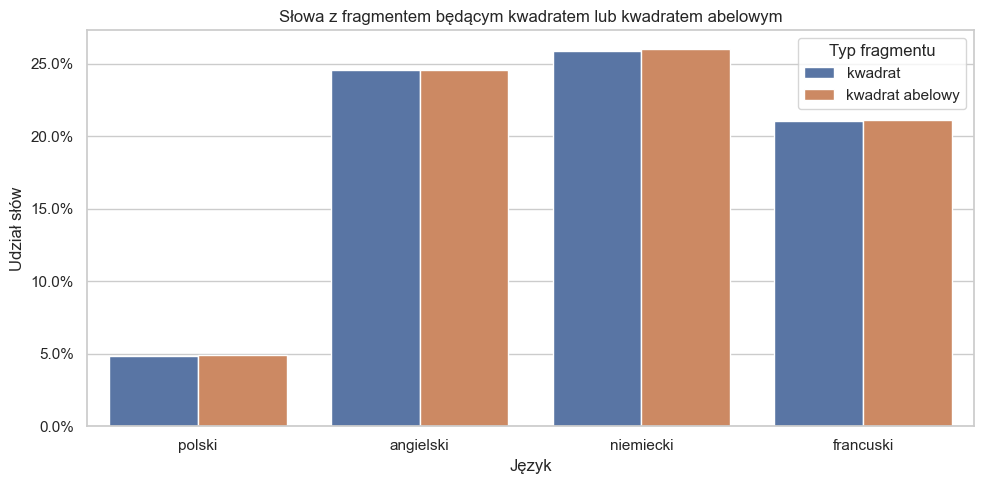

In [42]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=substring_presence_plot_df,
    x="language_label",
    y="percent_words",
    hue="structure_label",
)
ax.set_title("Słowa z fragmentem będącym kwadratem lub kwadratem abelowym")
ax.set_xlabel("Język")
ax.set_ylabel("Udział słów")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.legend(title="Typ fragmentu")
plt.tight_layout()
plt.show()

## 17. Słowa z największą liczbą znalezionych fragmentów

Wykres pokazuje słowa, w których detektory znalazły najwięcej fragmentów danego typu. Dane wejściowe: `top_substructure_words_plot_df`.

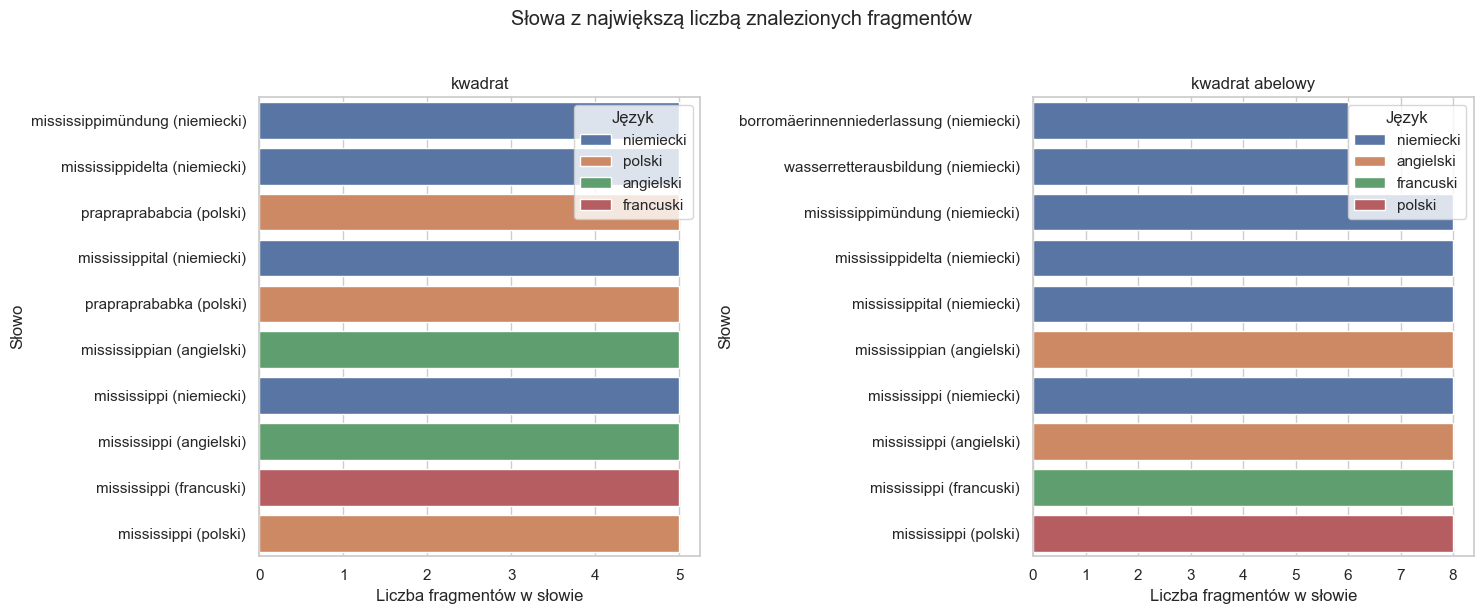

In [44]:
if top_substructure_words_plot_df.empty:
    print("Brak słów do narysowania rankingu.")
else:
    fig, axes = plt.subplots(1, len(SUBSTRING_STRUCTURES), figsize=(15, 6), sharex=False)
    if len(SUBSTRING_STRUCTURES) == 1:
        axes = [axes]

    for ax, structure in zip(axes, SUBSTRING_STRUCTURES, strict=True):
        plot_df = top_substructure_words_plot_df[top_substructure_words_plot_df["structure"] == structure].sort_values(
            "match_count"
        )
        sns.barplot(
            data=plot_df,
            x="match_count",
            y="word_label",
            hue="language_label",
            dodge=False,
            ax=ax,
        )
        ax.set_title(SUBSTRING_STRUCTURE_LABELS[structure])
        ax.set_xlabel("Liczba fragmentów w słowie")
        ax.set_ylabel("Słowo")
        ax.legend(title="Język")

    fig.suptitle("Słowa z największą liczbą znalezionych fragmentów", y=1.02)
    fig.tight_layout()
    plt.show()